# Linear feature-group comparison

This notebook compares Ridge regression across the three nested feature sets using the chronological validation sample. Holding the model class fixed isolates the incremental predictive contribution of conventional ownership and engineered network features. The test sample is not accessed.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator, PercentFormatter
from sklearn.metrics import mean_absolute_error

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.tabular_selection import (
    INITIAL_PARAMETERS,
    TARGET,
    fit_tabular_model,
    load_sample,
    performance,
    split_sample,
    transform_features,
)
from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE, SINGLE_PANEL_SIZE, apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
project = get_project_config()
set_matplotlib_style()

## Ridge feature-group comparison

In [8]:
sample = load_sample(
    paths.processed / 'modeling' / 'network_modeling_sample.parquet',
    'network_augmented',
)
train, validation, _ = split_sample(sample)

feature_labels = {
    'market': 'Market',
    'augmented': 'Market + ownership',
    'network_augmented': 'Market + ownership + network',
}
linear_rows = []
validation_prediction_frames = []
for feature_group, label in feature_labels.items():
    validation_predictions, bundle = fit_tabular_model(
        'ridge',
        feature_group,
        INITIAL_PARAMETERS['ridge'],
        train,
        validation,
        project.seed,
    )
    validation_metrics = performance(
        stage='ridge_feature_group_comparison',
        model=f'ridge_{feature_group}',
        model_class='ridge',
        feature_group=feature_group,
        sample=validation,
        predictions=validation_predictions,
    )
    train_x = transform_features(train, bundle['preprocessing'])
    raw_train_predictions = bundle['model'].predict(train_x)
    train_predictions = np.clip(raw_train_predictions, 0, 1)
    training_mae = mean_absolute_error(train[TARGET], train_predictions)
    prediction_frame = validation[['report_period', 'permno', TARGET]].copy()
    prediction_frame['feature_set'] = label
    prediction_frame['prediction'] = validation_predictions
    validation_prediction_frames.append(prediction_frame)

    singular_values = np.linalg.svd(train_x, compute_uv=False)
    alpha = float(INITIAL_PARAMETERS['ridge']['alpha'])
    effective_df = 1 + np.sum(
        singular_values**2 / (singular_values**2 + alpha)
    )
    train_target = train[TARGET].to_numpy(dtype=float)
    residual_sum_squares = np.sum(
        (train_target - raw_train_predictions) ** 2
    )
    total_sum_squares = np.sum(
        (train_target - train_target.mean()) ** 2
    )
    training_r2 = 1 - residual_sum_squares / total_sum_squares
    observations = len(train_target)
    adjusted_training_r2 = 1 - (1 - training_r2) * (observations - 1) / (
        observations - effective_df
    )
    residual_variance = residual_sum_squares / observations
    minus_twice_log_likelihood = observations * (
        np.log(2 * np.pi) + 1 + np.log(residual_variance)
    )
    aic = minus_twice_log_likelihood + 2 * effective_df
    bic = minus_twice_log_likelihood + np.log(observations) * effective_df

    linear_rows.append({
        'feature_set': label,
        'predictors': len(bundle['features']),
        'effective_df': effective_df,
        'training_mae': training_mae,
        'validation_mae': validation_metrics['mae'],
        'generalization_gap': validation_metrics['mae'] - training_mae,
        'adjusted_training_r2': adjusted_training_r2,
        'validation_r2': validation_metrics['r2'],
        'mean_quarterly_spearman': (
            validation_metrics['mean_quarterly_spearman']
        ),
        'AIC': aic,
        'BIC': bic,
    })

linear_comparison = pd.DataFrame(linear_rows)
market_validation_mae = linear_comparison.loc[
    linear_comparison['feature_set'].eq('Market'), 'validation_mae'
].item()
linear_comparison['MAE change vs market (pp)'] = (
    100 * (linear_comparison['validation_mae'] - market_validation_mae)
)
linear_comparison.to_csv(
    paths.tables / 'modeling' / 'ridge_feature_group_validation_comparison.csv',
    index=False,
)
display(linear_comparison.style.format({
    'effective_df': '{:.2f}',
    'training_mae': '{:.4f}',
    'validation_mae': '{:.4f}',
    'generalization_gap': '{:.4f}',
    'adjusted_training_r2': '{:.3f}',
    'validation_r2': '{:.3f}',
    'mean_quarterly_spearman': '{:.3f}',
    'AIC': '{:,.1f}',
    'BIC': '{:,.1f}',
    'MAE change vs market (pp)': '{:+.3f}',
}))

,feature_set,predictors,effective_df,training_mae,validation_mae,generalization_gap,adjusted_training_r2,validation_r2,mean_quarterly_spearman,AIC,BIC,MAE change vs market (pp)
0,Market,7,8.00,0.0869,0.0959,0.0089,0.344,0.449,0.747,"-169,213.7","-169,135.9",+0.000
1,Market + ownership,12,13.00,0.0869,0.0956,0.0088,0.345,0.452,0.746,"-169,470.6","-169,344.2",-0.024
2,Market + ownership + network,18,19.00,0.0868,0.0956,0.0088,0.346,0.453,0.746,"-169,637.1","-169,452.3",-0.030


## Error across realized validation drawdown deciles

The comparison below holds the linear model class fixed and shows whether expanding the feature set changes where validation errors are concentrated.

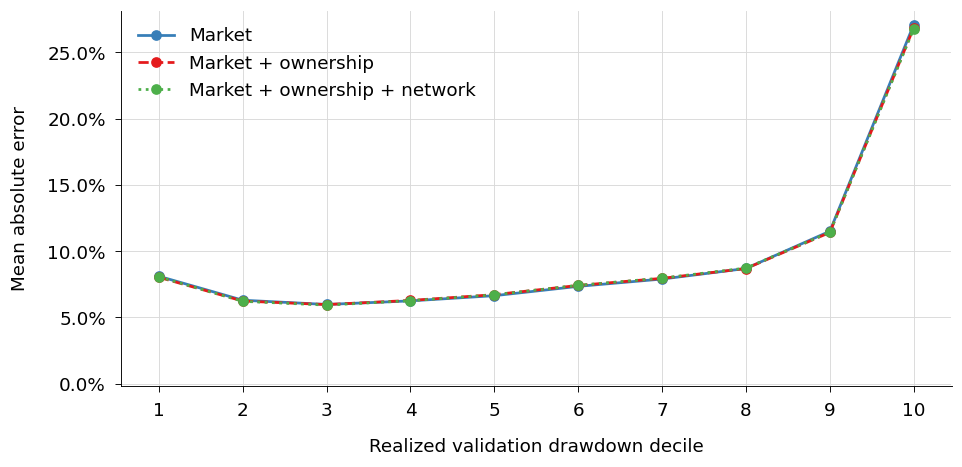

In [9]:
validation_prediction_table = pd.concat(
    validation_prediction_frames, ignore_index=True
)
validation_prediction_table['realized_drawdown_decile'] = np.ceil(
    10 * validation_prediction_table.groupby(
        ['feature_set', 'report_period']
    )[TARGET].rank(method='first', pct=True)
).astype(int).clip(1, 10)
validation_prediction_table['absolute_error'] = (
    validation_prediction_table[TARGET]
    - validation_prediction_table['prediction']
).abs()
ridge_decile_errors = validation_prediction_table.groupby(
    ['feature_set', 'realized_drawdown_decile'], as_index=False
).agg(
    observations=('permno', 'size'),
    mean_absolute_error=('absolute_error', 'mean'),
)
ridge_decile_errors.to_csv(
    paths.tables / 'modeling'
    / 'ridge_feature_group_validation_error_by_drawdown_decile.csv',
    index=False,
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
linestyles = ['-', '--', ':']

for index, (label, linestyle) in enumerate(
    zip(feature_labels.values(), linestyles)
):
    rows = ridge_decile_errors.loc[
        ridge_decile_errors['feature_set'].eq(label)
    ]
    axis.plot(
        rows['realized_drawdown_decile'],
        rows['mean_absolute_error'],
        marker='o',
        color=COLOR_PALETTE[index],
        linestyle=linestyle,
        label=label,
    )
axis.set_xlabel('Realized validation drawdown decile')
axis.set_ylabel('Mean absolute error')
axis.set_ylim(bottom=-0.002)
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures
    / '04_01_ridge_validation_mae_by_realized_drawdown_decile.pdf'
)
plt.show()